# EEG数据预处理
#  EEG Data Preprocessing

EEG深度学习项目的第一部分！
This is the first part of the EEG deep learning project!

在这个模块中，我们将专注于整个项目中最关键的基础——**数据预处理**。
In this module, we will focus on the most critical foundation of the entire project—**data preprocessing**.

### 为什么预处理如此重要？
### Why is preprocessing so important?

原始的EEG信号通常包含很多与我们研究无关的信息和噪声，例如：
Raw EEG signals often contain a lot of information and noise that are irrelevant to our research, such as:

- **基线漂移**：由头部轻微移动或设备本身引起的低频噪声。
- **Baseline Drift**: Low-frequency noise caused by slight head movements or the equipment itself.
- **高频噪声**：由肌肉活动（EMG）、电力线干扰（50/60Hz）等引起的高频干扰。
- **High-frequency Noise**: High-frequency interference caused by muscle activity (EMG), power line interference (50/60Hz), etc.
- **伪影（Artifacts）**：由眨眼、心跳等生理活动引起的突发性干扰。
- **Artifacts**: Abrupt interference caused by physiological activities like blinking or heartbeats.
- **量纲差异**：不同通道或不同实验记录的信号数值范围可能差异很大。
- **Scale Differences**: The numerical range of signals from different channels or experiments can vary significantly.

预处理的目标就是“清洗”这些原始数据，提取出与我们认知状态（“放松”与“专注”）最相关的信号特征，为后续的模型训练提供高质量的输入。
The goal of preprocessing is to "clean" this raw data, extracting the signal features most relevant to our cognitive states ("rest" and "focus") to provide high-quality input for subsequent model training.

### 本模块学习目标：
### Learning Objectives for This Module:

1.  **理解带通滤波**：学习为什么以及如何滤除无关的频率成分。
1.  **Understand Bandpass Filtering**: Learn why and how to filter out irrelevant frequency components.
2.  **掌握数据标准化**：了解Z-score标准化的作用和实现。
2.  **Master Data Standardization**: Understand the purpose and implementation of Z-score standardization.
3.  **学习滑动窗口技术**：明白如何从连续的时间序列中创建适合深度学习模型的样本。
3.  **Learn the Sliding Window Technique**: Understand how to create samples suitable for deep learning models from continuous time-series data.
4.  **构建PyTorch Dataset**：将所有预处理步骤封装到一个自定义的PyTorch `Dataset`类中，实现自动化数据加载。
4.  **Build a PyTorch Dataset**: Encapsulate all preprocessing steps into a custom PyTorch `Dataset` class to automate data loading.

## 步骤一：信号滤波 - 带通滤波器 (Bandpass Filter)
## Step 1: Signal Filtering - Bandpass Filter

我们的第一步是**滤波**。

Our first step is **filtering**.

对于EEG信号，我们通常只关心某个特定的频率范围。

For EEG signals, we are typically only interested in a specific frequency range.

例如，与认知活动相关的脑电波大多集中在4Hz到40Hz之间。

For example, brainwaves related to cognitive activities are mostly concentrated between 4Hz and 40Hz.

- **低于4Hz**的信号可能是缓慢的基线漂移。

- Signals **below 4Hz** are likely slow baseline drifts.
- **高于40Hz**的信号很可能是肌肉活动产生的噪声。

- Signals **above 40Hz** are likely noise generated from muscle activity.

**带通滤波器**就像一个“筛子”，它只允许特定频率范围（比如4-40Hz）的信号通过，而滤除（即丢弃）该范围之外的所有信号。

A **bandpass filter** acts like a "sieve"; it only allows signals within a specific frequency range (e.g., 4-40Hz) to pass through, while filtering out (i.e., discarding) all signals outside that range.

#### 技术选择：巴特沃斯滤波器 (Butterworth Filter)
#### Technical Choice: Butterworth Filter

我们选择巴特沃斯滤波器，因为它在通带（我们想要保留的频率范围）内具有“最大平坦”的特性，不会对信号波形造成不必要的扭曲。

We choose the Butterworth filter because it has a "maximally flat" characteristic in the passband (the frequency range we want to keep), which prevents unnecessary distortion of the signal's waveform.

#### 关键技术：零相位滤波 (`filtfilt`)
#### Key Technique: Zero-Phase Filtering (`filtfilt`)

标准的数字滤波器会引入**相位延迟**，即输出信号相对于输入信号在时间上会有一个微小的滞后。

Standard digital filters introduce **phase delay**, meaning the output signal has a slight time lag relative to the input signal.


这会破坏信号的精确定时信息。

This can corrupt the precise timing information of the signal.

为了解决这个问题，我们使用`filtfilt`函数，它会向前和向后各应用一次滤波器，从而完全抵消相位延迟，实现**零相位滤波**。

To solve this, we use the `filtfilt` function, which applies the filter once forward and once backward, thereby completely canceling out the phase delay and achieving **zero-phase filtering**.

In [1]:
# 导入所有必需的库
# Import all necessary libraries
import numpy as np # 导入 NumPy 库，用于高效的数值计算 / Import NumPy library for efficient numerical computation.
import pandas as pd # 导入 Pandas 库，用于数据处理和CSV文件读取 / Import Pandas library for data processing and reading CSV files.
import torch # 导入 PyTorch 核心库 / Import the core PyTorch library.
from torch.utils.data import Dataset, DataLoader # 从 PyTorch 导入 Dataset 和 DataLoader 类，用于构建数据管道 / From PyTorch, import Dataset and DataLoader classes for building data pipelines.
from scipy.signal import butter, filtfilt # 从 SciPy 导入 butter 和 filtfilt 函数，用于设计和应用数字滤波器 / From SciPy, import butter and filtfilt functions for designing and applying digital filters.
from sklearn.preprocessing import LabelEncoder # 从 Scikit-learn 导入 LabelEncoder，用于将文本标签转换为数字 / From Scikit-learn, import LabelEncoder for converting text labels to numbers.
import os # 导入 os 库，用于与操作系统交互，如处理文件路径 / Import the os library for interacting with the operating system, e.g., handling file paths.
import matplotlib.pyplot as plt # 导入 Matplotlib 的 pyplot 模块，用于数据可视化 / Import Matplotlib's pyplot module for data visualization.

# --- 带通滤波器函数 ---
# --- Bandpass Filter Function ---

def bandpass_filter(data, sampling_rate, lowcut, highcut): # 定义带通滤波器函数 / Define the bandpass filter function.
    """
    对输入数据应用一个4阶巴特沃斯带通滤波器。
    Applies a 4th-order Butterworth bandpass filter to the input data.

    参数 (Parameters):
    - data (np.ndarray): 输入的信号数据，形状为 (时间点数, 通道数)。/ Input signal data, with shape (number of time points, number of channels).
    - sampling_rate (int): 信号的采样率 (Hz)。/ The sampling rate of the signal (Hz).
    - lowcut (float): 低频截止频率 (Hz)。低于此频率的信号将被滤除。/ Low-frequency cutoff (Hz). Signals below this frequency will be filtered out.
    - highcut (float): 高频截止频率 (Hz)。高于此频率的信号将被滤除。/ High-frequency cutoff (Hz). Signals above this frequency will be filtered out.

    返回 (Returns):
    - y (np.ndarray): 滤波后的信号数据。/ The filtered signal data.
    """
    # 奈奎斯特频率是采样率的一半，是数字信号能有效表示的最高频率
    # The Nyquist frequency is half the sampling rate, representing the highest frequency a digital signal can effectively represent.
    nyq = 0.5 * sampling_rate
    # 将实际的截止频率转换为相对于奈奎斯特频率的归一化频率
    # Convert the actual cutoff frequencies to normalized frequencies relative to the Nyquist frequency.
    low = lowcut / nyq
    high = highcut / nyq
    
    # 使用 butter 函数设计一个4阶(order=4)的巴特沃斯滤波器
    # Design a 4th-order (order=4) Butterworth filter using the butter function.
    # 返回滤波器的分子(b)和分母(a)系数
    # It returns the numerator (b) and denominator (a) coefficients of the filter.
    b, a = butter(4, [low, high], btype='band')
    
    # 使用 filtfilt 函数对数据进行零相位滤波
    # Apply a zero-phase filter to the data using the filtfilt function.
    # 'filtfilt' 会向前和向后各应用一次滤波器，从而消除相位延迟
    # 'filtfilt' applies the filter once forward and once backward, thereby canceling out phase delay.
    # axis=0 表示沿着时间轴（第一个维度）进行滤波
    # axis=0 indicates that filtering is performed along the time axis (the first dimension).
    y = filtfilt(b, a, data, axis=0)
    
    return y # 返回滤波后的数据 / Return the filtered data.

print("Function 'bandpass_filter' has been successfully defined!") # 打印一条消息，确认函数已成功定义 / Print a message to confirm the function has been successfully defined.

Function 'bandpass_filter' has been successfully defined!


## 步骤二：构建PyTorch数据加载器 (EEGDataset)
## Step 2: Building the PyTorch Data Loader (EEGDataset)

在PyTorch中，我们通过创建一个继承自 `torch.utils.data.Dataset` 的自定义类来组织和处理数据。

In PyTorch, we organize and process data by creating a custom class that inherits from `torch.utils.data.Dataset`.

这个类就像一个自动化的数据处理流水线。

This class acts like an automated data processing pipeline.

我们需要实现三个核心方法：

We need to implement three core methods:

- `__init__(...)`: 构造函数。在这里完成所有数据的初始化操作，比如读取所有文件、应用预处理步骤（滤波、标准化、滑动窗口）等。它会在我们创建数据集实例时被一次性调用。
- `__init__(...)`: The constructor. All data initialization operations are completed here, such as reading all files and applying preprocessing steps (filtering, standardization, sliding window). It is called once when we create an instance of the dataset.
- `__len__(self)`: 返回数据集中样本的总数。
- `__len__(self)`: Returns the total number of samples in the dataset.
- `__getitem__(self, idx)`: 根据给定的索引 `idx`，返回一个样本（通常是数据和标签的元组）。DataLoader会调用这个方法来获取每一批次的数据。
- `__getitem__(self, idx)`: Returns a sample (usually a tuple of data and its label) based on a given index `idx`. The DataLoader calls this method to fetch each batch of data.

#### 我们的预处理流水线：
#### Our Preprocessing Pipeline:

在`EEGDataset`的`__init__`方法中，我们将对每个原始CSV文件执行以下一系列操作：

In the `__init__` method of our `EEGDataset`, we will perform the following series of operations on each raw CSV file:

1.  **加载数据**：用Pandas读取CSV文件。

**Load Data**: Read the CSV file using Pandas.

2.  **滤波**：调用上面定义的 `bandpass_filter` 函数。

**Filter**: Call the `bandpass_filter` function defined above.

3.  **Z-score 标准化**：对每个通道独立进行。公式为 `(x - mean) / std`。这可以消除不同通道间的量纲差异，使模型更容易学习。


**Z-score Standardization**: Applied independently to each channel. The formula is `(x - mean) / std`. This eliminates scale differences between channels, making it easier for the model to learn.

4.  **裁剪 (Clipping)**：将所有信号值强制限制在一个固定范围内（例如-20到20），防止极端异常值对模型造成干扰。

**Clipping**: Forces all signal values into a fixed range (e.g., -20 to 20) to prevent extreme outliers from disrupting the model.

5.  **滑动窗口**：将连续信号切分成固定长度、有重叠的片段，作为独立的训练样本。

**Sliding Window**: Segments the continuous signal into fixed-length, overlapping windows, which serve as individual training samples.

In [2]:
class EEGDataset(Dataset): # 定义 EEGDataset 类，它继承自 PyTorch 的 Dataset 类 
    # Define the EEGDataset class, which inherits from PyTorch's Dataset class.
    """
    自定义的PyTorch数据集类，用于加载和预处理EEG数据。
    Custom PyTorch Dataset class for loading and preprocessing EEG data.
    """
    # __init__ 是类的构造函数，在创建类的实例时被调用
    # __init__ is the class constructor, called when an instance of the class is created.
    def __init__(self, root_folder, window_size=404, stride=202, sampling_rate=202):
        # 初始化用于存储处理后数据和标签的列表
        # Initialize two empty lists to store all processed data windows and their corresponding labels.
        self.data, self.labels = [], []
        # 获取根目录下所有子文件夹（即类别名称），并排序以确保每次运行的顺序一致
        # Get all subdirectory names (i.e., class names) under the root folder and sort them to ensure consistent order.
        self.classes = sorted([d for d in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, d))])
        # 使用 scikit-learn 的 LabelEncoder 将文本类别名称（如 "focus", "rest"）转换为数字（如 0, 1）
        # Create and fit a LabelEncoder from scikit-learn to convert string class names (e.g., "focus", "rest") into integers (e.g., 0, 1).
        self.label_encoder = LabelEncoder().fit(self.classes)
        # 存储脑电信号的采样率
        # Store the sampling rate of the EEG signal as a class attribute.
        self.sampling_rate = sampling_rate

        # 遍历每一个类别文件夹
        # Loop through each class folder.
        # enumerate 同时提供索引 (label_idx) 和值 (label)
        # enumerate provides both the index (label_idx) and the value (label).
        for label_idx, label in enumerate(self.classes):
            # 构建当前类别文件夹的完整路径
            # Construct the full path to the current class folder.
            class_path = os.path.join(root_folder, label)
            
            # 遍历当前类别文件夹中的所有文件
            # Loop through all files in the current class folder.
            for file in os.listdir(class_path):
                # 检查文件是否是 .csv 文件
                # Check if the file is a .csv file.
                if file.endswith('.csv'):
                    # 构建当前 CSV 文件的完整路径
                    # Construct the full path to the current CSV file.
                    file_path = os.path.join(class_path, file)
                    # 使用 try-except 块来捕获和处理可能的文件读取或处理错误
                    # Use a try-except block to catch and handle potential file reading or processing errors.
                    try:
                        # --- 数据处理流程 ---
                        # --- Data Processing Pipeline ---
                        
                        # 步骤 1: 加载数据 (只取16个通道)
                        # Step 1: Load data (taking only 16 channels).
                        full_data = pd.read_csv(file_path, skiprows=1, usecols=range(1, 17)).values.astype(np.float64)

                        # 步骤 2: 滤波
                        # Step 2: Filtering.
                        full_data = bandpass_filter(full_data, sampling_rate=self.sampling_rate, lowcut=4, highcut=40)

                        # 步骤 3: Z-score 标准化 (带安全检查)
                        # Step 3: Z-score Standardization (with a safety check).
                        for i in range(full_data.shape[1]): # 遍历数据的每一个通道（列）进行标准化 / Loop through each channel (column) of the data for standardization.
                            mean = np.mean(full_data[:, i]) # 计算当前通道的平均值 / Calculate the mean of the current channel.
                            std = np.std(full_data[:, i])   # 计算当前通道的标准差 / Calculate the standard deviation of the current channel.
                            if std > 1e-8: # 防止除以零 / Prevent division by zero.
                                full_data[:, i] = (full_data[:, i] - mean) / std # 应用 Z-score 标准化公式 / Apply the Z-score standardization formula.
                            else: # 如果标准差为零，则将该通道所有值设为0 / If the standard deviation is zero, set all values in this channel to 0.
                                full_data[:, i] = 0.0

                        # 步骤 4: 裁剪 (在窗口化之前)
                        # Step 4: Clipping (before windowing).
                        np.clip(full_data, -20.0, 20.0, out=full_data) # 将所有数据点的值限制在 -20 到 20 之间，以去除极端异常值 
                        # Clip all data point values between -20 and 20 to remove extreme outliers.
                        
                        # 步骤 5: 滑动窗口
                        # Step 5: Sliding Window.
                        start = 0 # 初始化滑动窗口的起始位置 / Initialize the starting position of the sliding window.
                        while start + window_size <= len(full_data): # 循环直到窗口的末端超出数据总长度 / Loop until the end of the window exceeds the total data length.
                            window = full_data[start : start + window_size] # 从完整数据中切分出一个窗口 / Slice a window from the full data.
                            self.data.append(window) # 将切分出的窗口添加到数据列表 / Add the sliced window to the data list.
                            self.labels.append(label_idx) # 将对应的数字标签添加到标签列表 / Add the corresponding numerical label to the labels list.
                            start += stride # 将起始位置向前移动一个步长的距离 / Move the starting position forward by one stride.
                            
                    except Exception as e: # 如果 try 块中发生任何错误，则捕获它 / If any error occurs in the try block, catch it.
                        print(f"!!! 处理文件 {file_path} 时出错: {e}") # 打印错误信息，方便调试 / Print the error message for debugging.

        # --- 最终转换和清理 ---
        # --- Final Conversion and Cleanup ---
        self.data = np.array(self.data, dtype=np.float32) # 将存储窗口的列表转换为一个大的 NumPy 数组，并指定数据类型为 float32 / Convert the list of windows into a large NumPy array with data type float32.
        self.labels = np.array(self.labels, dtype=np.int64) # 将标签列表也转换为 NumPy 数组，并指定数据类型为 int64 / Convert the labels list into a NumPy array as well, with data type int64.

        if np.isnan(self.data).any() or np.isinf(self.data).any(): # 检查处理后的数据中是否包含任何 NaN (非数字) 或 Inf (无穷大) 的值 / Check if the processed data contains any NaN (Not a Number) or Inf (Infinity) values.
            print("\n!!! 警告: 处理后发现 NaN 或 Inf 值，正在清理。") # 如果发现坏值，打印一条警告信息 / If bad values are found, print a warning message.
            self.data = np.nan_to_num(self.data, nan=0.0, posinf=0.0, neginf=0.0) # 将所有 NaN 和 Inf 值替换为 0.0，确保数据纯净 / Replace all NaN and Inf values with 0.0 to ensure data purity.
        
    def __len__(self): # 定义 __len__ 方法，它返回数据集中的样本总数 / Define the __len__ method, which returns the total number of samples in the dataset.
        # 返回数据集中样本的总数
        # Return the total number of samples in the dataset.
        return len(self.data)

    def __getitem__(self, idx): # 定义 __getitem__ 方法，根据索引获取单个数据样本 / Define the __getitem__ method to retrieve a single data sample by its index.
        # 根据索引 idx，返回对应的数据和标签
        # Based on the index idx, return the corresponding data and label.
        # 将 NumPy 数组转换为 PyTorch 的 Tensor
        # Convert the NumPy arrays to PyTorch Tensors.
        return torch.from_numpy(self.data[idx]), torch.from_numpy(np.array(self.labels[idx]))

print("EEGDataset has been successfully defined!") # 打印一条消息，确认类已成功定义 / Print a message to confirm the class has been successfully defined.

EEGDataset has been successfully defined!


## 步骤三：实际操作与演示

## Step 3: Practical Operation and Demonstration

理论和代码都有了，现在让我们直接使用项目中已经准备好的真实数据，看看`EEGDataset`是如何工作的。

Now that we have the theory and the code, let's use the real data already prepared in the project to see how `EEGDataset` works.

我们将用 `./dataset/train` 文件夹中的数据来实例化`EEGDataset`类。

We will instantiate the `EEGDataset` class using the data in the `./dataset/train` folder.

这将完整地展示从读取原始CSV文件到输出可供模型使用的Tensor的全过程。

This will fully demonstrate the entire process from reading the raw CSV files to outputting Tensors ready for the model.


Loading data from './dataset/train'...

Data loading and preprocessing complete!
--- Dataset Summary ---
Total samples generated (via sliding window): 3440
Class mapping: {np.str_('Alert'): np.int64(0), np.str_('Nervous'): np.int64(1), np.str_('Relaxed'): np.int64(2)}

--- First Sample Details ---
Data type: torch.float32
Data shape (Time Points, Channels): torch.Size([404, 16])
Label: 0 (Corresponding class: 'Alert')


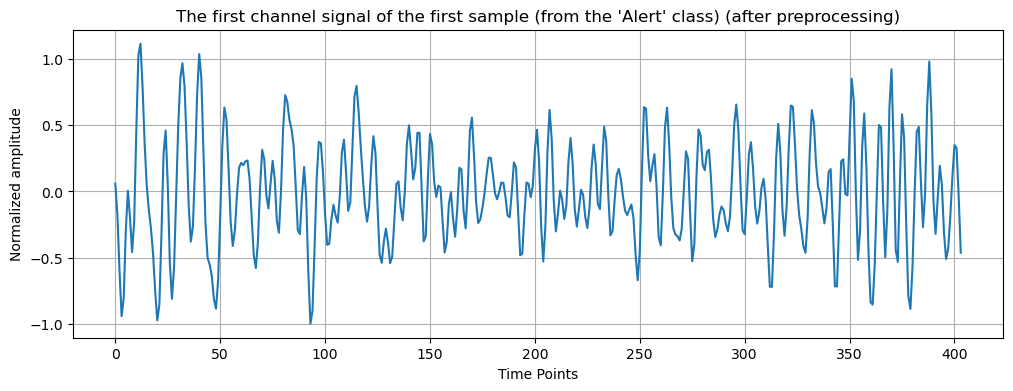

In [3]:
# --- 实例化并检查EEGDataset ---
# --- Instantiate and Inspect EEGDataset ---

# 定义你的实际训练数据文件夹路径
# Define the path to your actual training data folder.
train_data_path = "./dataset/train"

# 检查路径是否存在，提供更友好的提示
# Check if the path exists to provide a more user-friendly prompt.
if not os.path.isdir(train_data_path):
    # 如果路径不存在，打印错误信息 / If the path does not exist, print an error message.
    print(f"Error: Dataset path not found at '{train_data_path}'") # 中文注释: 打印错误信息
    # 打印提示信息，指导用户如何解决问题 / Print a hint to guide the user on how to solve the issue.
    print("Please ensure your notebook file and the 'dataset' folder are in the same directory.") # 中文注释: 打印提示信息
else:
    # 如果路径存在，打印加载信息 / If the path exists, print a loading message.
    print(f"Loading data from '{train_data_path}'...") # 中文注释: 打印加载信息
    # 使用你的实际训练数据文件夹来实例化 EEGDataset
    # 窗口大小404点（约2秒），步长202点（约1秒）
    train_dataset = EEGDataset(root_folder=train_data_path, window_size=404, stride=202)

    # --- 打印数据集信息 ---
    # --- Print Dataset Information ---
    if len(train_dataset) > 0: # 检查数据集是否成功生成了样本 / Check if the dataset has successfully generated any samples.
        print("\nData loading and preprocessing complete!") # 中文注释: 打印成功消息
        print("--- Dataset Summary ---") # 中文注释: 打印摘要标题
        print(f"Total samples generated (via sliding window): {len(train_dataset)}") # 中文注释: 打印通过滑动窗口生成的总样本数
        
        # 检查类别和它们的编码
        # Check the classes and their encodings.
        class_mapping = dict(zip(train_dataset.label_encoder.classes_, train_dataset.label_encoder.transform(train_dataset.label_encoder.classes_)))
        # 打印类别名称到数字标签的映射关系 / Print the mapping from class names to numerical labels.
        print(f"Class mapping: {class_mapping}") # 中文注释: 打印类别映射

        # 获取第一个样本并检查其属性
        # Get the first sample and inspect its properties.
        first_sample_data, first_sample_label = train_dataset[0]
        print(f"\n--- First Sample Details ---") # 中文注释: 打印样本详情标题
        print(f"Data type: {first_sample_data.dtype}") # 中文注释: 打印样本数据的类型
        print(f"Data shape (Time Points, Channels): {first_sample_data.shape}") # 中文注释: 打印样本数据的形状
        
        # 获取标签对应的类别名称
        # Get the class name corresponding to the label.
        label_name = train_dataset.label_encoder.inverse_transform([first_sample_label.item()])[0]
        # 打印样本的数字标签和其对应的原始类别名 / Print the sample's numerical label and its corresponding original class name.
        print(f"Label: {first_sample_label.item()} (Corresponding class: '{label_name}')") # 中文注释: 打印标签及其对应的类别名

        # 可视化第一个样本的第一个通道，直观感受数据经过完整预处理后的样子
        # Visualize the first channel of the first sample to intuitively see what the data looks like after the full preprocessing pipeline.
        plt.figure(figsize=(12, 4)) # 创建一个新的图形，并设置其大小 / Create a new figure and set its size.
        plt.plot(first_sample_data[:, 0].numpy()) # 绘制第一个通道的数据 / Plot the data of the first channel.

        # 设置图形的标题（英文） / Set the title of the plot (in English).
        plt.title(f"The first channel signal of the first sample (from the '{label_name}' class) (after preprocessing)")
        # 设置 x 轴的标签 / Set the label for the x-axis.
        plt.xlabel("Time Points")
        # 设置 y 轴的标签 / Set the label for the y-axis.
        plt.ylabel("Normalized amplitude")
        # 设置图形的标题（中文） / Set the title of the plot (in Chinese).
        #plt.title(f"第一个样本 (来自 '{label_name}' 类) 的第一个通道信号 (预处理后)")
        # 设置 x 轴的标签（中文） / Set the label for the x-axis (in Chinese).
        #plt.xlabel("时间点 (Time Points)")
        # 设置 y 轴的标签（中文） / Set the label for the y-axis (in Chinese).
        #plt.ylabel("标准化后的幅值")
        plt.grid(True) # 显示网格线 / Display grid lines.
        plt.show() # 显示图形 / Show the plot.
    else:
        # 如果数据集中没有样本，打印警告信息 / If there are no samples in the dataset, print a warning message.
        print(f"\nWarning: Data loading finished, but no samples were generated from '{train_data_path}'.") # 中文注释: 打印警告信息
        # 打印可能的原因，帮助用户排查问题 / Print possible reasons to help the user troubleshoot.
        print("Please check if your .csv files are empty, correctly formatted, or if the data length is sufficient to create a window.") # 中文注释: 打印可能的原因

## 模块一总结
## Module 1 Summary

我们完成了数据预处理模块的学习。
We have completed the data preprocessing module.

我们回顾一下核心知识点：
Let's review the core concepts:

- **为何预处理**：原始EEG信号充满噪声，需要清洗才能用于模型训练。

- **Why Preprocess**: Raw EEG signals are full of noise and need to be cleaned before they can be used for model training.
- **核心步骤**：我们实现了一个包含**滤波、标准化、裁剪和滑动窗口**的完整预处理流水线。

- **Core Steps**: We implemented a complete preprocessing pipeline that includes **filtering, standardization, clipping, and sliding windows**.

- **代码实现**：我们将所有逻辑都封装在了`EEGDataset`类中，这使得数据加载变得非常简单、高效和可复用。

- **Code Implementation**: We encapsulated all the logic into the `EEGDataset` class, which makes data loading simple, efficient, and reusable.

现在，我们已经拥有了高质量、格式统一的数据样本（Tensor），它们可以直接被输入到深度学习模型中。

Now, we have high-quality, uniformly formatted data samples (Tensors) that can be directly fed into a deep learning model.

在下一个模块中，我们将学习如何构建我们的**CNN+Transformer混合模型**。

In the next module, we will learn how to build our **CNN+Transformer hybrid model**.